# AF 8: Redes Neuronales Convolucionales

---
Hora: N5  Grupo: 007  Salon: 12206

José Juan Tamez Robledo             2001926

Ana Patricia Aguirre Leyzaola       2178178

Jorge Angel de Alejandro Martinez   2066801

Kevin Alejandro Sifuentes Martinez  2067313

Ricardo Alfredo Zumaya Osorio       2178139


---



1. Cargar librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

2. Cargar datos

In [4]:
(train_data, train_labels), (test_data, test_labels) = tf.keras.datasets.mnist.load_data()

print("Datos de entrenamiento:", train_data.shape)
print("Etiquetas de entrenamiento:", train_labels.shape)

print("Datos de prueba:", test_data.shape)
print("Etiquetas de prueba:", test_labels.shape)

Datos de entrenamiento: (60000, 28, 28)
Etiquetas de entrenamiento: (60000,)
Datos de prueba: (10000, 28, 28)
Etiquetas de prueba: (10000,)


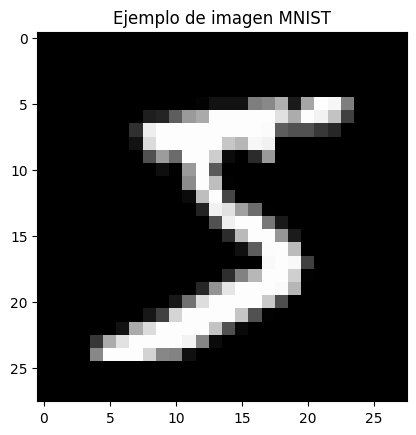

Etiqueta: 5


In [5]:
plt.imshow(train_data[0], cmap="gray")
plt.title("Ejemplo de imagen MNIST")
plt.show()

print("Etiqueta:", train_labels[0])

3. Preprocesamiento de datos

In [6]:
train_data = train_data / 255.0
test_data = test_data / 255.0

In [7]:
train_data = train_data.reshape(60000, 28, 28, 1)
test_data = test_data.reshape(10000, 28, 28, 1)

print("Train data:", train_data.shape)
print("Test data:", test_data.shape)

Train data: (60000, 28, 28, 1)
Test data: (10000, 28, 28, 1)


In [8]:
train_labels_categorical = tf.keras.utils.to_categorical(train_labels, 10)
test_labels_categorical = tf.keras.utils.to_categorical(test_labels, 10)

print("Etiqueta original:", train_labels[0])
print("Etiqueta categórica:", train_labels_categorical[0])

Etiqueta original: 5
Etiqueta categórica: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


4. Selección y entrenamiento del modelo

In [9]:
model = tf.keras.models.Sequential()

model.add(tf.keras.layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)))
model.add(tf.keras.layers.MaxPooling2D((2, 2)))

model.add(tf.keras.layers.Conv2D(64, (3, 3), activation="relu"))
model.add(tf.keras.layers.MaxPooling2D((2, 2)))

model.add(tf.keras.layers.Flatten())

model.add(tf.keras.layers.Dense(64, activation="relu"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = model.fit(
    train_data,
    train_labels_categorical,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 32ms/step - accuracy: 0.9538 - loss: 0.1541 - val_accuracy: 0.9827 - val_loss: 0.0587
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 31ms/step - accuracy: 0.9841 - loss: 0.0502 - val_accuracy: 0.9868 - val_loss: 0.0456
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 30ms/step - accuracy: 0.9896 - loss: 0.0340 - val_accuracy: 0.9876 - val_loss: 0.0427
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 80s 29ms/step - accuracy: 0.9918 - loss: 0.0264 - val_accuracy: 0.9866 - val_loss: 0.0501
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 31ms/step - accuracy: 0.9931 - loss: 0.0197 - val_accuracy: 0.9858 - val_loss: 0.0491


5. Prueba del modelo

In [13]:
test_loss, test_accuracy = model.evaluate(test_data, test_labels_categorical)

print("Pérdida en prueba:", test_loss)
print("Exactitud en prueba:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9857 - loss: 0.0470
Pérdida en prueba: 0.04696373641490936
Exactitud en prueba: 0.9857000112533569


Predicciones

In [14]:
predictions = model.predict(test_data)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


Predicción: 7
Valor real: 7


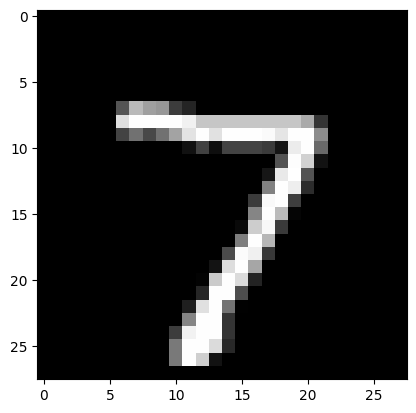

In [15]:
# Predicción 1
indice = 0

print("Predicción:", np.argmax(predictions[indice]))
print("Valor real:", test_labels[indice])

plt.imshow(test_data[indice].reshape(28, 28), cmap="gray")
plt.show()

Predicción: 0
Valor real: 0


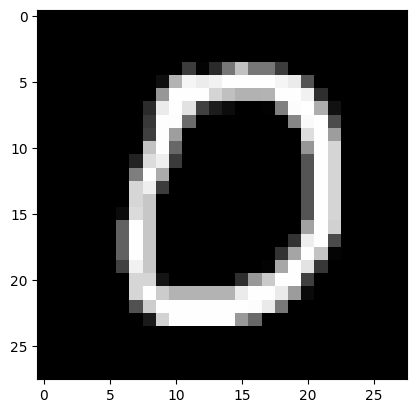

In [16]:
# Predicción 2
indice = 10

print("Predicción:", np.argmax(predictions[indice]))
print("Valor real:", test_labels[indice])

plt.imshow(test_data[indice].reshape(28, 28), cmap="gray")
plt.show()

Predicción: 0
Valor real: 0


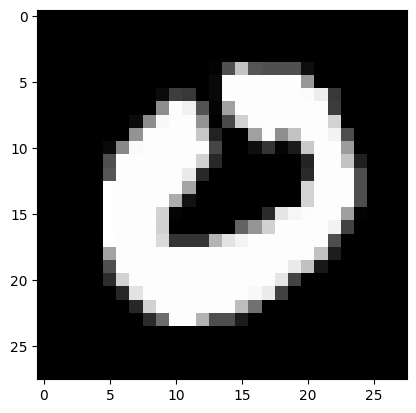

In [17]:
# Predicción 3
indice = 25

print("Predicción:", np.argmax(predictions[indice]))
print("Valor real:", test_labels[indice])

plt.imshow(test_data[indice].reshape(28, 28), cmap="gray")
plt.show()

Predicción: 6
Valor real: 6


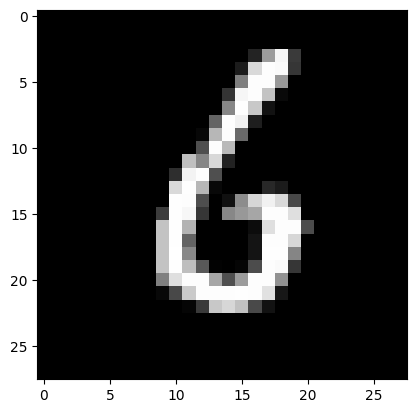

In [18]:
# Predicción 4
indice = 50

print("Predicción:", np.argmax(predictions[indice]))
print("Valor real:", test_labels[indice])

plt.imshow(test_data[indice].reshape(28, 28), cmap="gray")
plt.show()

Predicción: 6
Valor real: 6


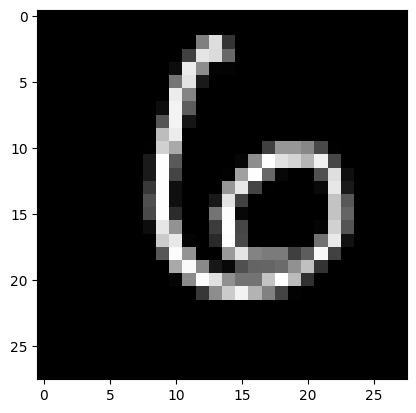

In [19]:
# Predicción 5
indice = 100

print("Predicción:", np.argmax(predictions[indice]))
print("Valor real:", test_labels[indice])

plt.imshow(test_data[indice].reshape(28, 28), cmap="gray")
plt.show()

Gráfica del entrenamiento

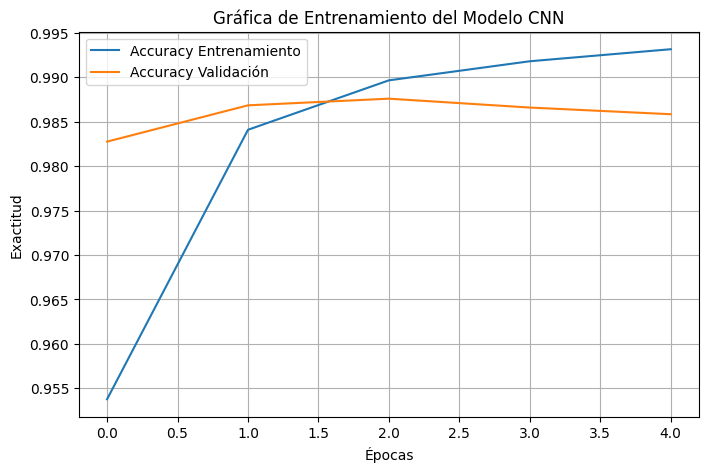

In [21]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Accuracy Entrenamiento")
plt.plot(history.history["val_accuracy"], label="Accuracy Validación")

plt.xlabel("Épocas")
plt.ylabel("Exactitud")
plt.title("Gráfica de Entrenamiento del Modelo CNN")

plt.legend()
plt.grid()
plt.show()